In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix

In [2]:
df=pd.read_csv("playtennis.csv")

df=pd.DataFrame(df)
print(df.head())

    Outlook Temperature Humidity    Wind PlayTennis
0     Sunny         Hot     High    Weak         No
1  Overcast        Mild   Normal  Strong         No
2  Overcast        Cool   Normal     NaN        Yes
3      Rain        Mild     High  Strong         No
4      Rain         Hot   Normal    Weak        Yes


In [3]:
df.info()
df.describe(include="all")
df.head()
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      200 non-null    object
 1   Temperature  200 non-null    object
 2   Humidity     191 non-null    object
 3   Wind         190 non-null    object
 4   PlayTennis   200 non-null    object
dtypes: object(5)
memory usage: 7.9+ KB
Missing Values:
Outlook         0
Temperature     0
Humidity        9
Wind           10
PlayTennis      0
dtype: int64

Duplicate Rows: 141


In [4]:
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(exclude="object").columns

print("Categorical Columns:", cat_cols.tolist())
print("Numerical Columns:", num_cols.tolist())

Categorical Columns: ['Outlook', 'Temperature', 'Humidity', 'Wind', 'PlayTennis']
Numerical Columns: []


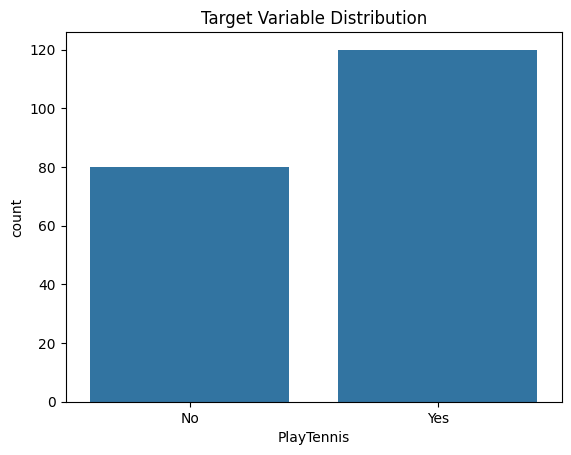

In [5]:
sns.countplot(x="PlayTennis", data=df)
plt.title("Target Variable Distribution")
plt.show()

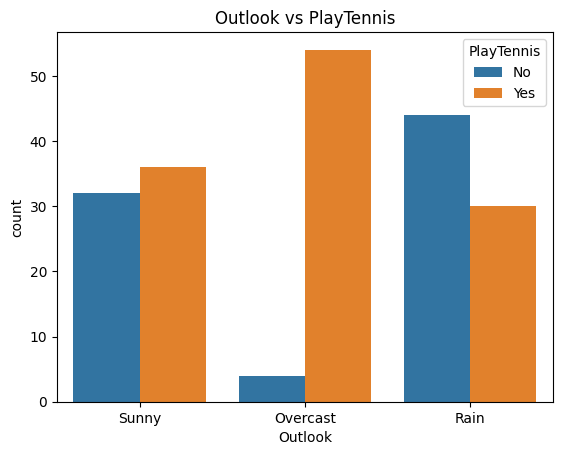

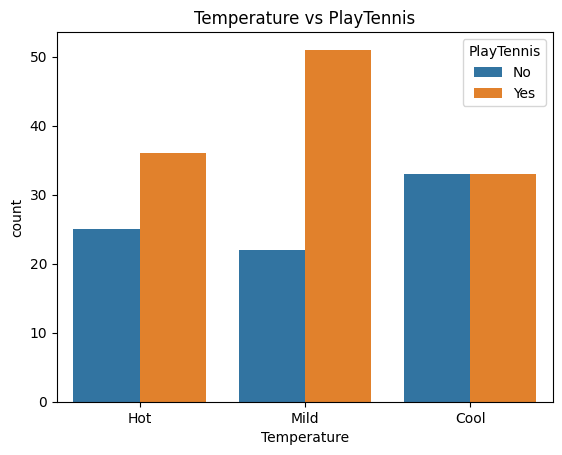

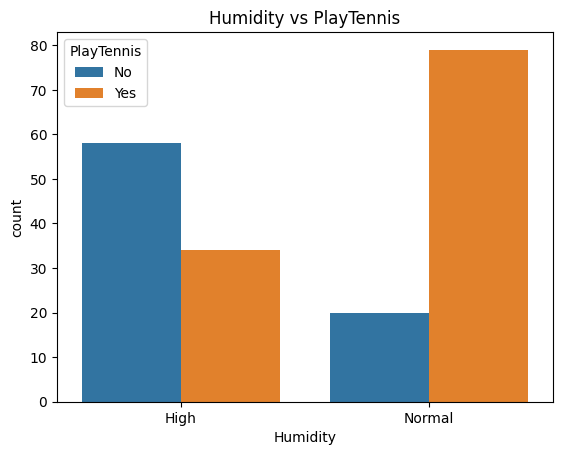

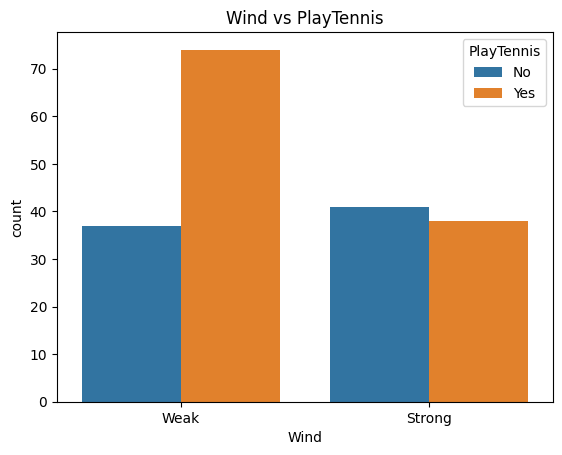

In [6]:
for col in cat_cols:
    if col != "PlayTennis":
        sns.countplot(x=col, hue="PlayTennis", data=df)
        plt.title(f"{col} vs PlayTennis")
        plt.show()

In [7]:
df["Wind"] = df["Wind"].fillna(df["Wind"].mode()[0])

df.isnull().sum()

Outlook        0
Temperature    0
Humidity       9
Wind           0
PlayTennis     0
dtype: int64

In [8]:
le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

df

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,2,1,0,1,0
1,0,2,1,0,0
2,0,0,1,1,1
3,1,2,0,0,0
4,1,1,1,1,1
...,...,...,...,...,...
195,1,2,0,1,1
196,0,1,0,0,1
197,2,2,1,0,1
198,1,2,0,1,1


In [9]:
X = df.drop("PlayTennis", axis=1)
y = df["PlayTennis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(160, 4) (40, 4)


In [16]:
# Set experiment name
try:
    mlflow.create_experiment("PlayTennis Classification")
except:
    pass
mlflow.set_experiment("PlayTennis Classification")
mlflow.set_tracking_uri(uri="http://127.0.0.1:5000/")

In [17]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

accuracies = {}
losses = {}

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        # Train model
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)
        
        # Calculate metrics
        acc = accuracy_score(y_test, y_pred)
        loss = log_loss(y_test, y_prob)
        
        # Store metrics for comparison
        accuracies[name] = acc
        losses[name] = loss
        
        # Log parameters
        mlflow.log_param("model_type", name)
        if name == "KNN":
            mlflow.log_param("n_neighbors", 5)
        elif name == "Random Forest":
            mlflow.log_param("n_estimators", 100)
            
        # Log metrics
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("log_loss", loss)
        
        # Log model
        mlflow.sklearn.log_model(model, name.replace(" ", "_").lower())
        
        print(f"{name} - Accuracy: {acc:.4f}, Loss: {loss:.4f}")

2026/01/26 10:03:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/26 10:03:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logistic Regression - Accuracy: 0.7750, Loss: 0.5080
🏃 View run Logistic Regression at: http://127.0.0.1:5000/#/experiments/1/runs/3484861286fa4cddabb22a4f8b59630c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/01/26 10:03:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


KNN - Accuracy: 0.9250, Loss: 1.0538
🏃 View run KNN at: http://127.0.0.1:5000/#/experiments/1/runs/7ef0aa88aa674d468eed4275cf1c81b0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Decision Tree - Accuracy: 0.9500, Loss: 0.9886
🏃 View run Decision Tree at: http://127.0.0.1:5000/#/experiments/1/runs/32c2cb46bc2149328df05e4dc6d5a63f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


2026/01/26 10:03:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Random Forest - Accuracy: 0.9000, Loss: 0.9978
🏃 View run Random Forest at: http://127.0.0.1:5000/#/experiments/1/runs/02bb179d1570447fa9cb51a49bf35022
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [12]:
final_results = pd.DataFrame({
    "Model": accuracies.keys(),
    "Accuracy": accuracies.values(),
    "Loss": losses.values()
})

final_results

,Model,Accuracy,Loss
0,Logistic Regression,0.775,0.508044
1,KNN,0.925,1.053774
2,Decision Tree,0.950,0.988644
3,Random Forest,0.900,0.997800


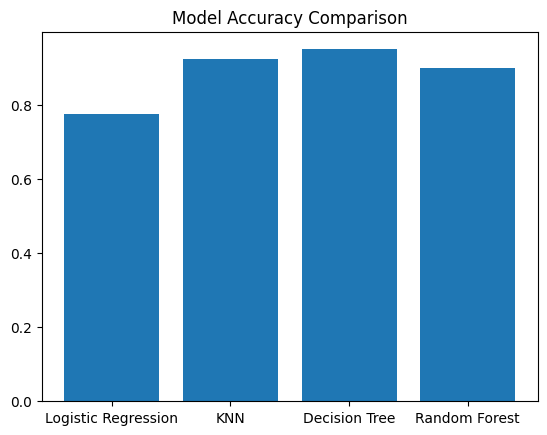

In [13]:
plt.figure()
plt.bar(accuracies.keys(), accuracies.values())
plt.title("Model Accuracy Comparison")
plt.show()

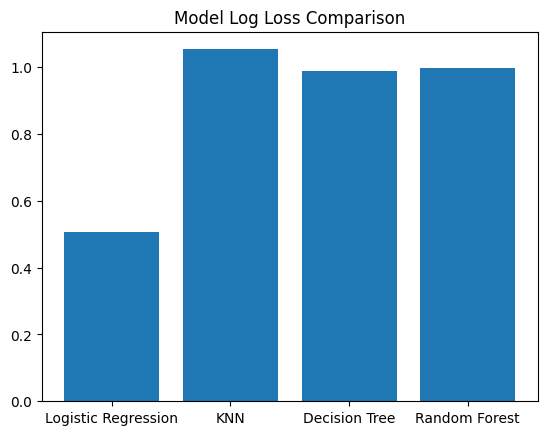

In [14]:
plt.figure()
plt.bar(losses.keys(), losses.values())
plt.title("Model Log Loss Comparison")
plt.show()